<a href="https://colab.research.google.com/github/kate-marine/logistic-injury-prediction-modeling/blob/main/logistic_injury_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Using Logistic Modeling to Improve Player Injury Predictions in the English Premier League




### Background and Motivation

Predicting player injuries is one of the most biggest challenges in elite football analytics. Professional clubs collect workload, recovery, and GPS-based tracking data on every player and session, hoping to help inform which players are most likely to get hurt and when. Modern analytics literature has responded by reaching for increasingly complex tools such gradient boosting, random forests, deep neural networks, under the assumption that more sophisticated models will yield better predictions. But in a domain where model outputs inform high-stakes decisions about human bodies, predictive accuracy is not the only thing that matters. Interpretability is a key piece that matters as well.

This project investigates a question the intersection of these concerns: can a well-specified logistic regression model, incorporating domain-informed nonlinear and interaction terms, achieve predictive performance comparable to ensemble methods reported in the literature on EPL injury prediction? And if so, what does this imply for the interpretability-performance tradeoff in applied sports analytics?


The motivation for this question comes from Chang et al.'s "Football Analytics: Assessing the Correlation between Workload, Injury and Performance of Football Players in the English Premier League" (2024). The authors apply gradient boosting, random forest, and decision tree models to EPL tracking data, achieving AUC values in the range of 0.69–0.72. Their results highlight an important pattern that often gets glossed over which is that returns to model sophistication diminish quickly. The performance gap between their simplest and most complex specifications is modest, and all of their models operate as effective black boxes. They are capable of producing risk scores but not of explaining, in terms a medical staff can act on, why a given player is flagged.

This matters because injury prediction in elite sport is not a pure prediction problem. It is a decision-support problem. When a model identifies a player as high-risk, the question that immediately follows from coaches and medical staff is why. Should training load be reduced? Is recovery the issue? Is the schedule the problem? An XGBoost feature importance plot or a SHAP value can attempt at answers, but a logistic regression coefficient, expressed as an odds ratio, can give one directly. (For example an additional match in the prior seven days raises injury odds by approximately 23%). These are numbers a performance scientist can integrate into workload-management decisions whereas a black-box risk score is not.

Given this, the goal of this paper is to test whether a simpler probabilistic model can approach the predictive power of more computationally intensive algorithms while preserving the interpretability that applied practitioners require.

### Methods

I generate a dataset of 8,000 match-level observations (400 players × 20 matches) modeled after EPL workload, context, and GPS dynamics, and fit a sequence of four logistic regression models of increasing specification: a workload-only baseline (A), a model adding player and match context (B), a full model adding GPS-derived intensity metrics (C), and a nonlinear extension (C′) that adds squared and interaction terms designed to capture fatigue amplification under congested schedules. I evaluate these models against Chang et al.'s reported benchmarks using AUC and average precision under group-level cross-validation.

**Core research questions:**

- Can a well-specified logistic regression model (with domain-informed nonlinear and interaction terms) achieve predictive performance comparable to ML ensemble methods reported in literature for EPL injury prediction?
- If so what does this imply for the interpretability-performance tradeoff in applied sports analytics?

Part 1 questions:

- How much does contextual information (position, home/away, opponent strength, age, team quality) actually improve predictions?
- Do GPS-based intensity measures (distance, accelerations, sprint load) add unique predictive value?


###Part 1: Simulating the data


Changes from original data simulation:
- GPS metrics are NOT just minutes * rate — they include per-player intensity + per-match noise.
- Injury logit depends on GPS (and GPS×congestion), not only minutes/rest.
- Context (position, home/away, team medical quality) meaningfully shifts risk.

In [1]:
# imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             roc_curve, confusion_matrix, classification_report, brier_score_loss)

RNG_SEED = 42
np.random.seed(RNG_SEED)

# Simulates an EPL-like panel with unique GPS signal context effects
def simulate_epl_dataset(n_players=400, n_matches_per_player=20, seed=RNG_SEED, n_teams=20):

    rng = np.random.default_rng(seed)

    # identities and base attributes
    N = n_players * n_matches_per_player
    player_ids = np.repeat(np.arange(n_players), n_matches_per_player)

    # assign teams per player then repeat
    player_team = rng.integers(0, n_teams, size=n_players)
    team_ids = np.repeat(player_team, n_matches_per_player)

    # per player baseline intensity (how "hard" a player moves regardless of minutes)
    player_intensity = rng.normal(0, 0.40, size=n_players)
    intensity_rep = np.repeat(player_intensity, n_matches_per_player)

    # age and position
    age_player = rng.normal(26, 3.5, size=n_players).clip(18, 38)
    age = np.repeat(age_player, n_matches_per_player)
    position = rng.choice(['DF','MF','FW'], p=[0.4,0.4,0.2], size=N)

    # match/workload and context (pre-match info)
    minutes_last     = rng.integers(0, 95, size=N)
    days_since_last  = rng.choice([3,4,5,6,7], p=[.2,.25,.25,.2,.1], size=N)
    congestion_7d    = rng.integers(0, 3, size=N)  # matches in last 7 days
    home_away        = rng.integers(0, 2, size=N)  # 1=home 0=away
    opponent_strength= rng.normal(0, 1, size=N)

    # GPS-like metrics with unique signal
    # base per-match rates + player intensity + micro-noise
    base_sprint_rate   = rng.normal(0.40, 0.06, size=N)
    base_distance_rate = rng.normal(110, 12, size=N)
    base_accel_rate    = rng.normal(0.60, 0.10, size=N)
    sprints_3  = (minutes_last * (base_sprint_rate + 0.10*intensity_rep) + rng.normal(0, 1.6, size=N)).clip(0) #was 2.0
    distance_3 = (minutes_last * (base_distance_rate +  8.0*intensity_rep) + rng.normal(0,12.0, size=N)).clip(0) # was 15.0
    accels_3   = (minutes_last * (base_accel_rate  + 0.15*intensity_rep) + rng.normal(0, 2.5, size=N)).clip(0) #was 3.0

    # composite GPS features
    accel_density = accels_3 / np.maximum(distance_3, 1)        # intensity per meter
    dist_per_min  = distance_3 / np.maximum(minutes_last, 1)    # work rate

    # team medical quality (protective context)
    team_med_quality = rng.normal(0, 0.60, size=n_teams)  # higher = better protection
    team_quality = team_med_quality[team_ids]

    # injury label: richer logit w/ GPS and interactions
    # standardize some GPS composites to keep coefficients on reasonable scales
    def z(x): return (x - x.mean()) / (x.std() + 1e-6)
    accel_z        = z(accels_3)
    accel_density_z= z(accel_density)
    dist_per_min_z = z(dist_per_min)

    logit = (
        -3.0                                                 # sets base prevalence ~10–12%
        + 0.006*minutes_last                                 # exposure
        - 0.14*(days_since_last - 5)                         # rest protective
        + 0.30*congestion_7d                                 # schedule congestion
        + 0.10*opponent_strength                             # tougher opponents
        + 0.28*(position=='FW') + 0.12*(position=='MF')      # attackers riskier (vs DF baseline)
        - 0.08*(home_away==1)                                # slight home protection
        - 0.18*team_quality                                  # better medical setup means fewer injuries

        # GPS adds unique risk beyond minutes
        + 0.225*accel_z  # was 0.18 (increasing by 25%)                                 # more accelerations means higher risk
        + 0.175*dist_per_min_z    #was 0.14                            # high work-rate per minute

        # interactions: fatigue hits harder when congested
        + 0.10*((minutes_last/90.0) * congestion_7d) #keep as it
        + 0.15*(accel_z * congestion_7d) #was 0.12
    )

    p = 1/(1+np.exp(-logit))
    injured_next = rng.binomial(1, p)

# Returns dataframe with extra columns: team_id, team_quality (protective), accel_density, dist_per_min (GPS composites)
    return pd.DataFrame({
        'player_id': player_ids,
        'team_id': team_ids,
        'team_quality': team_quality,      # ADDED context feature (protective)
        'position': position,
        'age': age,
        'minutes_last': minutes_last,
        'days_since_last': days_since_last,
        'congestion_7d': congestion_7d,
        'home_away': home_away,
        'opponent_strength': opponent_strength,
        'sprints_3': sprints_3,
        'distance_3': distance_3,
        'accels_3': accels_3,
        'accel_density': accel_density,    # ADDED GPS composite
        'dist_per_min': dist_per_min,      # can take out
        'target_injured_next_match': injured_next
    })

# Generate the simulated dataset and show preview
df = simulate_epl_dataset()
print(df.columns.tolist())
print("Preview:\n", df.head())

print("Prevalence:", df['target_injured_next_match'].mean().round(3))



['player_id', 'team_id', 'team_quality', 'position', 'age', 'minutes_last', 'days_since_last', 'congestion_7d', 'home_away', 'opponent_strength', 'sprints_3', 'distance_3', 'accels_3', 'accel_density', 'dist_per_min', 'target_injured_next_match']
Preview:
    player_id  team_id  team_quality position        age  minutes_last  \
0          0        1      0.775824       MF  24.177941            49   
1          0        1      0.775824       MF  24.177941            87   
2          0        1      0.775824       FW  24.177941            43   
3          0        1      0.775824       MF  24.177941            37   
4          0        1      0.775824       MF  24.177941             8   

   days_since_last  congestion_7d  home_away  opponent_strength  sprints_3  \
0                4              2          1          -0.121279  22.833816   
1                3              2          0           0.334882  38.712052   
2                3              1          0           0.605312  13.56

GroupKFold split to divide the data into training and validation sets

*   A problem I faced with the dataset was that each player appears multiple times, so in order to avoid data leakage I needed to make sure each player should appear once in both train and validation sets.



In [2]:
from sklearn.model_selection import GroupKFold

#Target and features
target = 'target_injured_next_match'

# Include all features
categorical = ['position', 'home_away']
numeric = [
    'age', 'minutes_last', 'days_since_last', 'congestion_7d',
    'opponent_strength', 'team_quality',          # new context var
    'sprints_3', 'distance_3', 'accels_3', 'accel_density'  # GPS metrics
]

# Define X/y and player groups (for group-aware splitting)
X = df[categorical + numeric]
y = df[target].values
groups = df['player_id'].values

# GroupKFold split (ensures same player doesn't appear in both sets)
gkf = GroupKFold(n_splits=5)
train_idx, val_idx = list(gkf.split(X, y, groups))[0]

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print("Train size:", X_train.shape, "Validation size:", X_val.shape)
print("Positive rate in train:", y_train.mean().round(3),
      "| val:", y_val.mean().round(3))



Train size: (6400, 12) Validation size: (1600, 12)
Positive rate in train: 0.114 | val: 0.109


###Set up

####Preprocessing Pipeline

Encode categorical variables and standardize numeric ones. Put into clean numeric matrix that model can then actually use and is applied identically to validation/test data. Also should avoid leakage since is fit only on training data.


steps here:
- Encode categoricals (strings like position, binary flags like home_away) → one-hot vectors.
- Scale numeric features (e.g., minutes_last, congestion_7d) → zero mean / unit variance.
- Bundle  all in a single Pipeline so split,fit, transform process is safe and repeatable. Can be reused on val/test.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preproc = ColumnTransformer([
    # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical), # Added a comma here
    ('num', StandardScaler(), numeric)
])

In [4]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer

# categorical = ['position', 'home_away']
# numeric = ['age','minutes_last','days_since_last','congestion_7d',
#            'opponent_strength','sprints_3','distance_3','accels_3']

# preproc = ColumnTransformer(
#     transformers=[
#         # Categorical: impute (if needed) + one-hot
#         ('cat', Pipeline(steps=[
#             ('impute', SimpleImputer(strategy='most_frequent')),
#             ('ohe', OneHotEncoder(handle_unknown='ignore'))  # keeps val-time unseen cats safe
#         ]), categorical),

#         # Numeric: impute (if needed) + scale
#         ('num', Pipeline(steps=[
#             ('impute', SimpleImputer(strategy='median')),
#             ('scale', StandardScaler())
#         ]), numeric)
#     ],
#     remainder='drop'
# )


Visualize the result of the ColumnTransformer by applying it to the training data:

In [5]:
X_train_transformed = preproc.fit_transform(X_train)

# convert numpPy array back to dataframe
# check if column order differen
feature_names = preproc.get_feature_names_out()
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)

print("Original training data shape:", X_train.shape)
print("Transformed training data shape:", X_train_transformed.shape)
print("\nTransformed data (first 5 rows):")
display(X_train_transformed_df.head())

Original training data shape: (6400, 12)
Transformed training data shape: (6400, 13)

Transformed data (first 5 rows):


,cat__position_FW,cat__position_MF,cat__home_away_1,num__age,num__minutes_last,num__days_since_last,num__congestion_7d,num__opponent_strength,num__team_quality,num__sprints_3,num__distance_3,num__accels_3,num__accel_density
0,0.0,1.0,1.0,-0.463424,0.077543,-0.622754,1.229831,-0.126691,1.420647,0.343297,0.014683,0.261772,-0.049484
1,0.0,1.0,0.0,-0.463424,1.465318,-1.410428,1.229831,0.326247,1.420647,1.693169,1.799475,1.520351,-0.057221
2,1.0,0.0,0.0,-0.463424,-0.141579,-1.410428,0.003831,0.594766,1.420647,-0.445078,-0.292364,-0.147063,-0.051507
3,0.0,1.0,1.0,-0.463424,-0.360702,-1.410428,-1.222168,1.959448,1.420647,-0.423078,-0.444774,-0.025098,-0.042678
4,0.0,1.0,0.0,-0.463424,-1.419793,0.164919,-1.222168,-0.982299,1.420647,-1.393026,-1.369010,-1.317435,-0.057539


####Fit Baseline Models (Dummy + Logistic Regression)

Wanted to start with a dummy classifier (predicts majority class) to compare against the model.
Then will train main logistic regression model.

Dummy baseline - preliminary model that should predict no injury for everyone. Using as a floor for AUC/AP that the logistic model should beat.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report
)


dummy = Pipeline([
    ('prep', preproc),
    ('clf', DummyClassifier(strategy='most_frequent'))
])
dummy.fit(X_train, y_train)
proba_dummy = dummy.predict_proba(X_val)[:, 1]

auc_dummy = roc_auc_score(y_val, proba_dummy)
ap_dummy  = average_precision_score(y_val, proba_dummy)
print(f"AUC (Dummy): {auc_dummy:.3f}  |  AP (Dummy): {ap_dummy:.3f}")

# Visuals

# positive prevalance
yhat_dummy = dummy.predict(X_val)
print("Positive prevalence in validation:", f"{y_val.mean():.3%}")
# Confusion matrix
print("\nConfusion matrix — Dummy (most_frequent):")
print(confusion_matrix(y_val, yhat_dummy))
#classification report
print("\nClassification report — Dummy (most_frequent):")
print(classification_report(y_val, yhat_dummy, digits=3, zero_division=0))

dummy_strat = Pipeline([('prep', preproc),
                        ('clf', DummyClassifier(strategy='stratified', random_state=42))])
dummy_strat.fit(X_train, y_train)
proba_strat = dummy_strat.predict_proba(X_val)[:, 1]



AUC (Dummy): 0.500  |  AP (Dummy): 0.109
Positive prevalence in validation: 10.875%

Confusion matrix — Dummy (most_frequent):
[[1426    0]
 [ 174    0]]

Classification report — Dummy (most_frequent):
              precision    recall  f1-score   support

           0      0.891     1.000     0.942      1426
           1      0.000     0.000     0.000       174

    accuracy                          0.891      1600
   macro avg      0.446     0.500     0.471      1600
weighted avg      0.794     0.891     0.840      1600



Interpretation

Prevalence: 10.875% of validation examples are injuries (positives).

Confusion matrix - predicts “no injury” for everyone, so it never catches a true injury.

Class 0 (no injury)
 Precision = 0.891 (because 89.1% of the set is actually no-injury)
 Recall = 1.000 (it predicts 0 for everyone, so it “recovers” all actual 0s)


Class 1 (injury)
 Precision = 0.000, Recall = 0.000,
 There are no predicted positives, so precision/recall are 0 by convention.

Accuracy = 0.891 - This equals the share of negatives in the data. It’s misleadingly high despite missing every injury.


Chance levels
AUC (Dummy) = 0.500 makes sense because the probabilities are constant.

AP (Dummy) = 0.109
about equal to the prevalence (10.9%), which is what you expect for a chance classifier

Essentially the dummy model is a baseline that always predicts no injury achieves high accuracy (0.891) solely because injuries are rare (10.9% prevalence), but it recovers 0% of injuries (recall = 0.00).



## Part 2 Creating Logistic model


I implemented all models using scikit-learn pipelines with standardized numeric predictors and one-hot encoding for categorical variables. For model evaluation I used a GroupKFold cross-validation split (to ensure player-level independence) and two primary performance metrics:

A_Workload            AUC=0.709  AP=0.221
B_Workload+Context    AUC=0.716  AP=0.235
C_All(+GPS)           AUC=0.736  AP=0.246


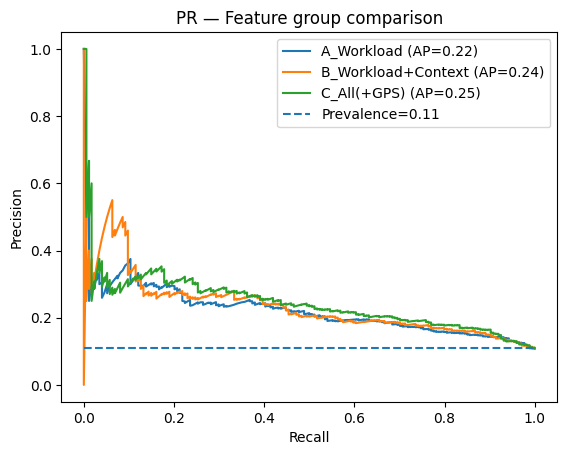

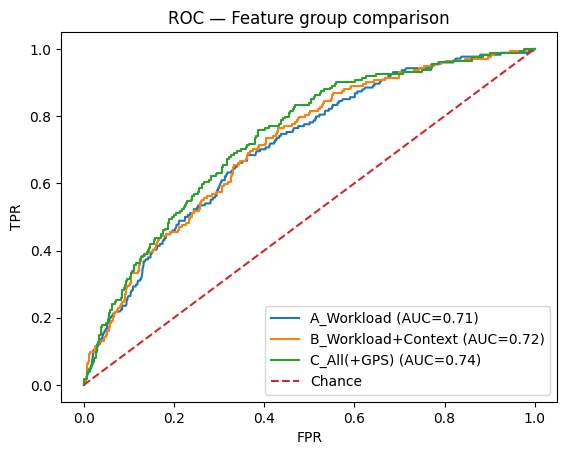

,AUC,AP
A_Workload,0.708835,0.221453
B_Workload+Context,0.716210,0.235001
C_All(+GPS),0.736309,0.245677


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

# Define feature groups for A/B/C models
workload = ['minutes_last','days_since_last','congestion_7d']
context  = ['position','home_away','opponent_strength','age','team_quality']  # added team_quality
gps      = ['sprints_3','distance_3','accels_3','accel_density']              # added accel_density

A_cat, A_num = [], workload
B_cat, B_num = ['position','home_away'], workload + ['opponent_strength','age','team_quality']
C_cat, C_num = ['position','home_away'], workload + ['opponent_strength','age','team_quality'] + gps


def make_pipe(cat_cols, num_cols):
    pre = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])
    pipe = Pipeline([
        ('prep', pre),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))
    ])
    return pipe

# Define feature sets
# workload = ['minutes_last','days_since_last','congestion_7d']
# context  = ['position','home_away','opponent_strength','age']
# gps      = ['sprints_3','distance_3','accels_3']

# A: workload only
A_cat = []              ; A_num = workload
# B: workload + context
B_cat = ['position','home_away']; B_num = workload + ['opponent_strength','age']
# C: workload + context + GPS
C_cat = ['position','home_away']; C_num = workload + ['opponent_strength','age'] + gps

models = {
    'A_Workload': make_pipe(A_cat, A_num),
    'B_Workload+Context': make_pipe(B_cat, B_num),
    'C_All(+GPS)': make_pipe(C_cat, C_num),
}

metrics = {}
probas = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, p)
    ap  = average_precision_score(y_val, p)
    metrics[name] = {'AUC': auc, 'AP': ap}
    probas[name]  = p
    print(f"{name:20s}  AUC={auc:.3f}  AP={ap:.3f}")

# Plots
prev = y_val.mean()

# PR overlay
plt.figure()
for name, p in probas.items():
    prec, rec, _ = precision_recall_curve(y_val, p)
    plt.plot(rec, prec, label=f'{name} (AP={average_precision_score(y_val,p):.2f})')
plt.hlines(prev, 0, 1, linestyles='--', label=f'Prevalence={prev:.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR — Feature group comparison')
plt.legend(); plt.show()

# ROC overlay
plt.figure()
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_val, p)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val,p):.2f})')
plt.plot([0,1],[0,1],'--', label='Chance')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — Feature group comparison')
plt.legend(); plt.show()

pd.DataFrame(metrics).T


**Precision Recall Curve:**
The precision–recall curves show that all models perform substantially better than random classification (baseline = 0.11). The orange curve (B) lies between A and C, meaning contextual variables help but don’t shift precision dramatically. Precision also drops as recall increases which is expected because as you capture more true injuries, you also start capturing more false positives. So essentially including contextual variables modestly improves early precision, while adding GPS-derived intensity measures produces the most consistent gain in precision across recall levels. This indicates that GPS metrics contribute unique predictive information beyond workload and context features.

**ROC Curve:**
The ROC curves demonstrate progressive improvement across models, with AUC increasing from 0.71 (workload-only) to 0.74 (full model). The smooth upward separation of the green curve (C_All(+GPS)) from the blue and orange curves confirms that GPS-derived features improve the model’s ability to correctly rank high-risk players without increasing false alarms.

## Part 3: Adding nonlinear & interaction terms
Targeted terms that make most sense:
- minutes × congestion (because fatigue hits harder in dense schedules)
- minutes² (risk accelerates at high loads)
- age² (U-shape possibility)
- rest spline (bucket rest days to allow nonlinearity)





create features (make sure no leakage):

In [8]:
df_nl = df.copy()

# interactions and polynomials (raw units) -check scaler will handle scale
df_nl['minutes_x_cong'] = df_nl['minutes_last'] * df_nl['congestion_7d']
df_nl['minutes_sq']     = df_nl['minutes_last']**2
df_nl['age_sq']         = df_nl['age']**2

# simple piecewise for rest (bins become categoricals)
df_nl['rest_bin'] = pd.cut(df_nl['days_since_last'], bins=[-1,3,5,10], labels=['≤3','4–5','≥6'])

# rebuild X/y/groups for same split indices
X_nl = df_nl.drop(columns=['target_injured_next_match'])
y_nl = df_nl['target_injured_next_match'].values
groups_nl = df_nl['player_id'].values

# same indices as before to keep fair comparison
Xtr_nl, Xva_nl = X_nl.iloc[train_idx], X_nl.iloc[val_idx]
ytr_nl, yva_nl = y_nl[train_idx], y_nl[val_idx]


Define columns for the nonlinear model C′ (C plus the new terms):

In [9]:
cat_cols_nl = ['position','home_away','rest_bin']
num_cols_nl = ['age','age_sq','minutes_last','minutes_sq','days_since_last','congestion_7d',
               'minutes_x_cong','opponent_strength','sprints_3','distance_3','accels_3']

pre_nl = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_nl),
    ('num', StandardScaler(), num_cols_nl)
])
logit_nl = Pipeline([
    ('prep', pre_nl),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', solver='liblinear'))
])

logit_nl.fit(Xtr_nl, ytr_nl)
p_nl = logit_nl.predict_proba(Xva_nl)[:,1]
auc_nl = roc_auc_score(yva_nl, p_nl)
ap_nl  = average_precision_score(yva_nl, p_nl)
print(f"Logit + interactions  AUC={auc_nl:.3f}  AP={ap_nl:.3f}")


Logit + interactions  AUC=0.739  AP=0.252


interpretation: see paper results section (also to do)

In [10]:
# see which new terms mattered
ohe = logit_nl.named_steps['prep'].named_transformers_['cat']
scaler = logit_nl.named_steps['prep'].named_transformers_['num']

feat_cat = list(ohe.get_feature_names_out(['position','home_away','rest_bin']))
feat_num = ['age','age_sq','minutes_last','minutes_sq','days_since_last','congestion_7d',
            'minutes_x_cong','opponent_strength','sprints_3','distance_3','accels_3']
feats = feat_cat + feat_num
coefs = logit_nl.named_steps['clf'].coef_.ravel()
import pandas as pd, numpy as np
pd.DataFrame({'feature':feats,'coef':coefs,'odds_ratio':np.exp(coefs)})\
  .sort_values('odds_ratio',ascending=False).head(12)




,feature,coef,odds_ratio
14,distance_3,0.495284,1.640964
5,age,0.412832,1.511091
15,accels_3,0.405471,1.500008
10,congestion_7d,0.167306,1.182116
12,opponent_strength,0.152463,1.164699
0,position_FW,0.126730,1.135110
11,minutes_x_cong,0.103170,1.108679
3,rest_bin_≤3,0.059979,1.061814
4,rest_bin_≥6,0.055794,1.057380
8,minutes_sq,0.039736,1.040536


Because numerics were scaled, the coefs are per 1 standard deviation so I wanted to get odds ratios for raw-unit changes. This way can translate the model’s abstract coefficients into their actual real-world effects.

In [11]:
num_cols = ['age','age_sq','minutes_last','minutes_sq','days_since_last',
            'congestion_7d','minutes_x_cong','opponent_strength',
            'sprints_3','distance_3','accels_3']

# pull scaler SDs and betas
scaler = logit_nl.named_steps['prep'].named_transformers_['num']
scales = scaler.scale_
betas  = logit_nl.named_steps['clf'].coef_.ravel()

# map feature to beta (align with cat then num order)
ohe = logit_nl.named_steps['prep'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(['position','home_away','rest_bin'])) + num_cols
beta_map = dict(zip(feat_names, betas))

def OR_delta(feature, delta_raw):
    j = num_cols.index(feature)
    beta_std = beta_map[feature]
    return float(np.exp(beta_std * (delta_raw / scales[j])))

print("OR for +10 minutes:", OR_delta('minutes_last', 10))
print("OR for +1 rest day:", OR_delta('days_since_last', 1))
print("OR for +1 match in 7d:", OR_delta('congestion_7d', 1))

OR for +10 minutes: 0.8834494718657626
OR for +1 rest day: 0.890859803751631
OR for +1 match in 7d: 1.2276687259664336


interpretation:
The model estimates that adding 1 match in the prior week increases injury odds by ≈ 23%, while an additional day of rest lowers injury odds by ≈ 9%. A +10-minute increase in playing time raises injury risk by about 9% as well. These magnitudes are directionally consistent with empirical sports-medicine findings that dense match schedules and inadequate recovery elevate injury likelihood.

(OR > 1 = higher odds of injury, OR < 1 = lower odds.)


### Calibration plot

Should indicate how well-calibrated  predicted probabilities are i.e. whether the probabilities the model outputs (x-axis) match the true observed frequency of injuries (y-axis)

Calibration plot


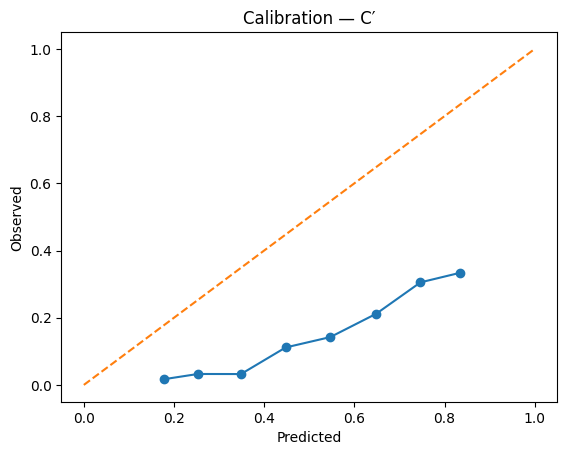

In [12]:
# Calibration plot
print(f"Calibration plot")
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(yva_nl, p_nl, n_bins=10)
import matplotlib.pyplot as plt
plt.plot(prob_pred, prob_true, marker='o'); plt.plot([0,1],[0,1],'--')
plt.xlabel('Predicted'); plt.ylabel('Observed'); plt.title('Calibration — C′')
plt.show()

interpretation: Because the blue curve is below the diagonal almost everywhere it means the model’s predicted probabilities are too high relative to the true rate so it’s overconfident. In other words the C′ model discriminates well between higher- and lower-risk cases (as AUC ≈ 0.74 shows), but it overestimates absolute injury probabilities, particularly in the mid- to high-risk range.

If I had more time I would try to improve this and think about applying a CalibratedClassifierCV with isotonic regression or Platt scaling on the validation data to bring the blue curve closer to the diagonal

Comparing C' to earlier models

C_All(+GPS):  AUC= 0.7362286598636166  AP= 0.24548980543374477


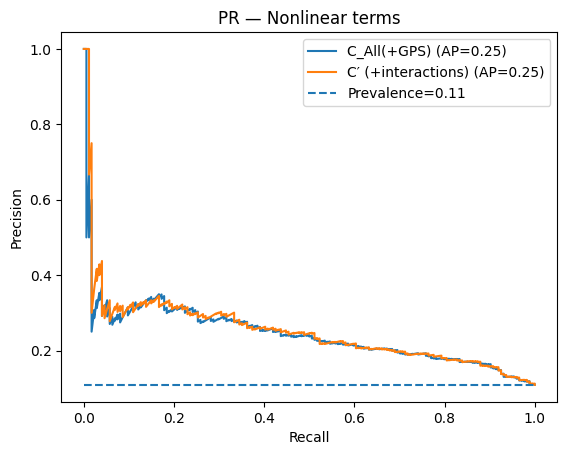

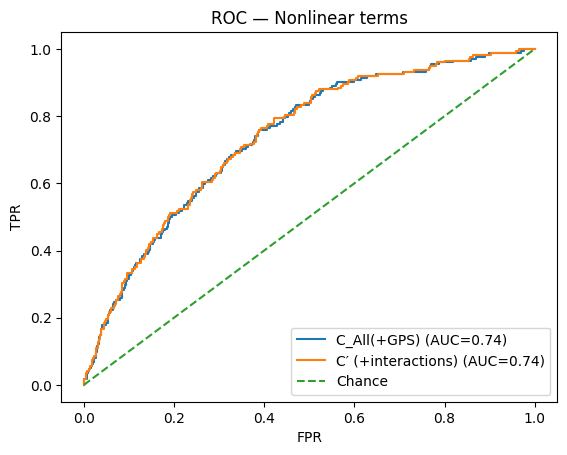

In [13]:
# Refit c model on the same df_nl slices but without the new features
pre_c = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ['position','home_away']),
    ('num', StandardScaler(), ['age','minutes_last','days_since_last','congestion_7d',
                               'opponent_strength','sprints_3','distance_3','accels_3'])
])
logit_c = Pipeline([
    ('prep', pre_c),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))
]).fit(Xtr_nl, ytr_nl)

p_c = logit_c.predict_proba(Xva_nl)[:,1]
print("C_All(+GPS):  AUC=", roc_auc_score(yva_nl, p_c), " AP=", average_precision_score(yva_nl, p_c))


#plot PR/ROC C vs C'
# PR
plt.figure()
for name, p in {'C_All(+GPS)': p_c, 'C′ (+interactions)': p_nl}.items():
    pr, rc, _ = precision_recall_curve(yva_nl, p)
    plt.plot(rc, pr, label=f'{name} (AP={average_precision_score(yva_nl,p):.2f})')
plt.hlines(yva_nl.mean(), 0, 1, linestyles='--', label=f'Prevalence={yva_nl.mean():.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR — Nonlinear terms')
plt.legend(); plt.show()

# ROC
plt.figure()
for name, p in {'C_All(+GPS)': p_c, 'C′ (+interactions)': p_nl}.items():
    fpr, tpr, _ = roc_curve(yva_nl, p)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(yva_nl,p):.2f})')
plt.plot([0,1],[0,1],'--', label='Chance')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — Nonlinear terms')
plt.legend(); plt.show()


In [14]:
# one comparison table
comp = pd.DataFrame({
    'A_Workload'        : metrics['A_Workload'],
    'B_Workload+Context': metrics['B_Workload+Context'],
    'C_All(+GPS)'       : metrics['C_All(+GPS)'],
}).T
comp = comp.assign(
    Cprime_AUC = auc_nl,
    Cprime_AP  = ap_nl
)
comp


,AUC,AP,Cprime_AUC,Cprime_AP
A_Workload,0.708835,0.221453,0.738538,0.252428
B_Workload+Context,0.716210,0.235001,0.738538,0.252428
C_All(+GPS),0.736309,0.245677,0.738538,0.252428


interpretation: see paper results section